In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

stocks_names = ['reliance', 'tcs', 'infosys', 'hdfc_bank', 'wipro']
clean_data = {}

for name in stocks_names:
    df = pd.read_csv(f'../data/cleaned/{name}_clean.csv', index_col=0, parse_dates=True)
    clean_data[name] = df

print("All cleaned data loaded! ✅")

All cleaned data loaded! ✅


In [2]:
for name, df in clean_data.items():
    df['Daily_Return'] = df['Close'].pct_change() * 100
    
print("Daily returns calculated! ✅")
clean_data['reliance'][['Close', 'Daily_Return']].head()

Daily returns calculated! ✅


,Close,Daily_Return
Date,,
2024-01-01,1279.692871,NaN
2024-01-02,1290.290039,0.828102
2024-01-03,1276.259277,-1.087411
2024-01-04,1282.854736,0.516780
2024-01-05,1288.313843,0.425544


In [4]:
for name, df in clean_data.items():
    avg_return = np.mean(df['Daily_Return'].dropna())
    volatility = np.std(df['Daily_Return'].dropna())
    print(f"{name.upper()} — Avg Daily Return: {avg_return:.3f}% | Volatility: {volatility:.3f}%")
    df

RELIANCE — Avg Daily Return: -0.016% | Volatility: 1.445%
TCS — Avg Daily Return: 0.052% | Volatility: 1.331%
INFOSYS — Avg Daily Return: 0.108% | Volatility: 1.440%
HDFC_BANK — Avg Daily Return: 0.034% | Volatility: 1.411%
WIPRO — Avg Daily Return: 0.115% | Volatility: 1.762%


In [5]:
combined = pd.DataFrame()

for name, df in clean_data.items():
    combined[name] = df['Close']

combined.head()

,reliance,tcs,infosys,hdfc_bank,wipro
Date,,,,,
2024-01-01,1279.692871,3501.880859,1429.636108,826.441040,223.164413
2024-01-02,1290.290039,3476.244629,1414.015869,826.927734,219.446198
2024-01-03,1276.259277,3392.214355,1373.099365,814.176575,213.225723
2024-01-04,1282.854736,3369.288818,1394.018311,822.912537,211.588776
2024-01-05,1288.313843,3434.619629,1412.311157,818.702698,213.553116


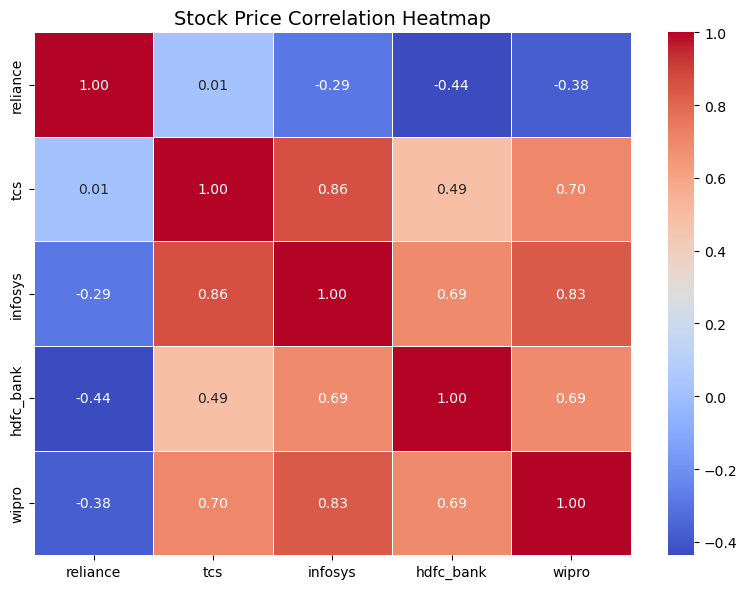

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Stock Price Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../visuals/correlation_heatmap.png', dpi=150)
plt.show()

In [6]:
correlation = combined.corr()
correlation

,reliance,tcs,infosys,hdfc_bank,wipro
reliance,1.000000,0.014423,-0.289504,-0.436508,-0.378299
tcs,0.014423,1.000000,0.862624,0.487770,0.698172
infosys,-0.289504,0.862624,1.000000,0.694827,0.831873
hdfc_bank,-0.436508,0.487770,0.694827,1.000000,0.694876
wipro,-0.378299,0.698172,0.831873,0.694876,1.000000


In [8]:
import os
os.makedirs('../visuals', exist_ok=True)
print("Visuals folder ready! ✅")

Visuals folder ready! ✅


In [10]:
for name, df in clean_data.items():
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    df['MA_200'] = df['Close'].rolling(window=200).mean()

print("Moving averages calculated! ✅")
clean_data['reliance'][['Close', 'MA_50', 'MA_200']].tail()

Moving averages calculated! ✅


,Close,MA_50,MA_200
Date,,,
2024-12-23,1211.834717,1288.442556,1417.191922
2024-12-24,1212.280884,1285.481133,1416.036357
2024-12-26,1206.133911,1282.388342,1414.695300
2024-12-27,1210.595459,1279.949902,1413.301085
2024-12-30,1200.333862,1277.106953,1411.891133


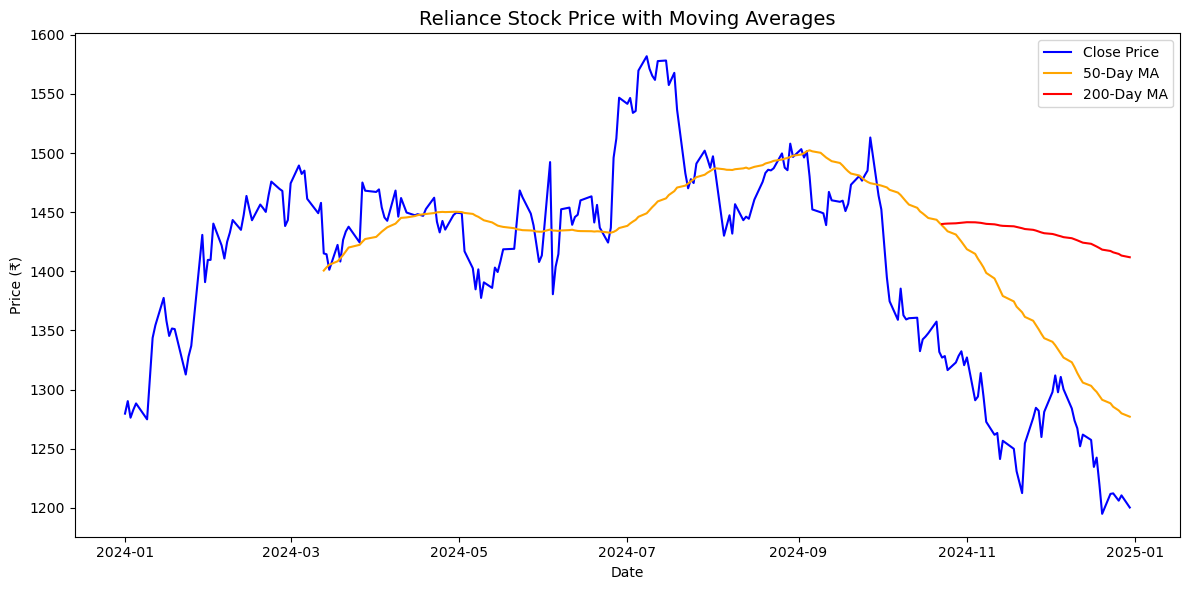

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(clean_data['reliance']['Close'], label='Close Price', color='blue')
plt.plot(clean_data['reliance']['MA_50'], label='50-Day MA', color='orange')
plt.plot(clean_data['reliance']['MA_200'], label='200-Day MA', color='red')
plt.title('Reliance Stock Price with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (₹)')
plt.legend()
plt.tight_layout()
plt.savefig('../visuals/reliance_moving_average.png', dpi=150)
plt.show()

In [12]:
performance = {}

for name, df in clean_data.items():
    start_price = df['Close'].iloc[0]
    end_price = df['Close'].iloc[-1]
    total_return = ((end_price - start_price) / start_price) * 100
    performance[name] = total_return

performance_df = pd.DataFrame(list(performance.items()), columns=['Stock', 'Total_Return_%'])
performance_df = performance_df.sort_values('Total_Return_%', ascending=False)
performance_df

,Stock,Total_Return_%
4,wipro,27.568995
2,infosys,26.745813
1,tcs,11.209957
3,hdfc_bank,6.129091
0,reliance,-6.201411


C:\Users\Administrator\AppData\Local\Temp\ipykernel_7120\2035625885.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=performance_df, x='Stock', y='Total_Return_%', palette='viridis')


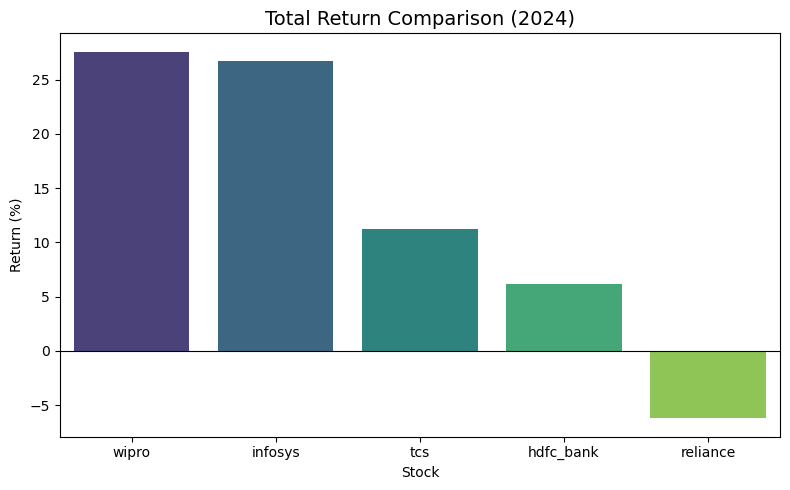

In [13]:
plt.figure(figsize=(8, 5))
sns.barplot(data=performance_df, x='Stock', y='Total_Return_%', palette='viridis')
plt.title('Total Return Comparison (2024)', fontsize=14)
plt.ylabel('Return (%)')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../visuals/performance_comparison.png', dpi=150)
plt.show()

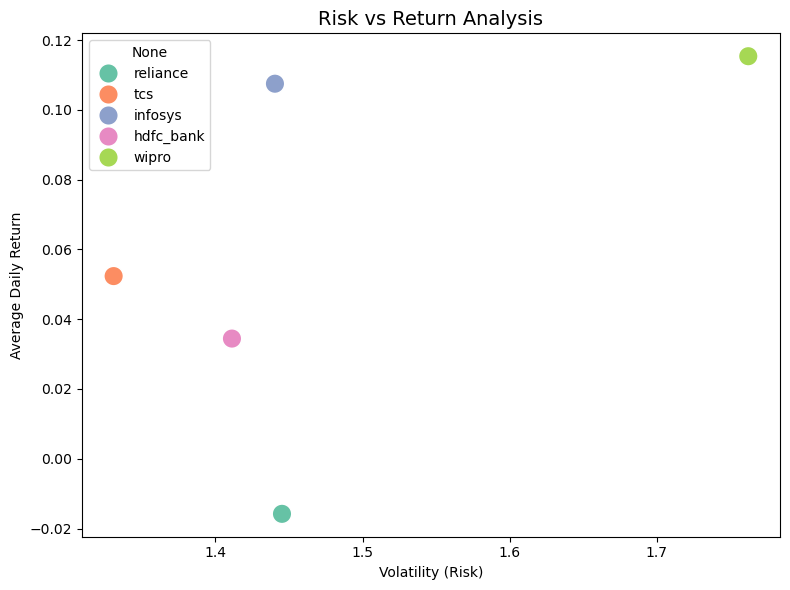

In [14]:
risk_return = pd.DataFrame()

for name, df in clean_data.items():
    risk_return.loc[name, 'Avg_Return'] = np.mean(df['Daily_Return'].dropna())
    risk_return.loc[name, 'Volatility'] = np.std(df['Daily_Return'].dropna())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=risk_return, x='Volatility', y='Avg_Return', s=200, hue=risk_return.index, palette='Set2')
plt.title('Risk vs Return Analysis', fontsize=14)
plt.xlabel('Volatility (Risk)')
plt.ylabel('Average Daily Return')
plt.tight_layout()
plt.savefig('../visuals/risk_return.png', dpi=150)
plt.show()